## K means clustering

MNIST bestaat uit plaatjes van cijfers (0 t/m 9).
Elk plaatje is een lijst van 784 pixelwaardes.
Om data te comprimeren willen we K means clustering toepassen om prototypes te maken.

### Opdracht 1

Wat stelt één prototype voor?

Waarom is dit geheugenbesparend?

Schrijf een functie **load_mnist** die:

- De MNIST-data laadt

- De pixelwaarden (eventueel) schaalt naar 0-1


**Wat stelt één prototype voor?**

Één prototype stelt een gemiddeld plaatje voor van een groep gelijkende cijfers. Het is het centrum van een cluster: een afbeelding van 784 pixels die de meest typische verschijningsvorm van een bepaald cijfer binnen die groep weergeeft.

**Waarom is dit geheugenbesparend?**

In plaats van alle trainingsbeelden op te slaan (bijv. 60.000 x 784 pixels), sla je alleen de prototypes op (bijv. 10 x k x 784 pixels). Als k klein is, is dit veel minder geheugen dan de volledige dataset.

In [1]:
from sklearn.datasets import fetch_openml
import numpy as np

def load_mnist():
    mnist = fetch_openml('mnist_784', version=1, as_frame=False)
    X = mnist.data / 255.0  # schaal naar 0-1
    y = mnist.target.astype(int)
    return X, y

X, y = load_mnist()
print("Data shape:", X.shape)
print("Labels shape:", y.shape)

Data shape: (70000, 784)
Labels shape: (70000,)


### Stap 2: Prototypes maken

We maken per cijfer een aantal prototypes (gemiddelde plaatjes).

Schrijf een functie **make_prototype** die:

- Voor elk cijfer (0-9) de bijbehorende trainingsbeelden selecteert

- Met K-means k clusters maakt

- Alle cluster-centers opslaat als prototypes

- Per prototype het juiste cijfer onthoudt

- Alle prototypes en bijbehorende labels in een datastructuur returnt


Hint:

- Gebruik een for-loop over de cijfer waardes (0 - 9)

- maak van elk van de waardes een lijstje van de afbeeldingen die erij horen

- Je mag KMeans uit sklearn.cluster gebruiken om van dit lijstje een prototype te maken

    **km = KMeans(n_clusters=k)**

    vindt K groepen in de data

    **km.fit(X_digit)**

    je kunt de cluster centers (prototypes) achterhalen met:

    **km.cluster_centers_**

- Als alternatief mag je ook zelf het KMeans algoritem implementeren

Bedenk goed dat je functie terug moet geven: prototypes en labels. Denk na over welke datastructuur je hiervoor wilt gebruiken.


In [2]:
from sklearn.cluster import KMeans

def make_prototype(X_train, y_train, k=3):
    prototypes = []
    proto_labels = []

    for digit in range(10):
        # Selecteer alle afbeeldingen van dit cijfer
        X_digit = X_train[y_train == digit]

        # Maak k clusters met KMeans
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X_digit)

        # Sla de cluster centers op als prototypes
        for center in km.cluster_centers_:
            prototypes.append(center)
            proto_labels.append(digit)

    return np.array(prototypes), np.array(proto_labels)

Maak nu een stukje code waarmee je de bovenstaande functies aanroept en een (of meer) van de prototypes laat zien.

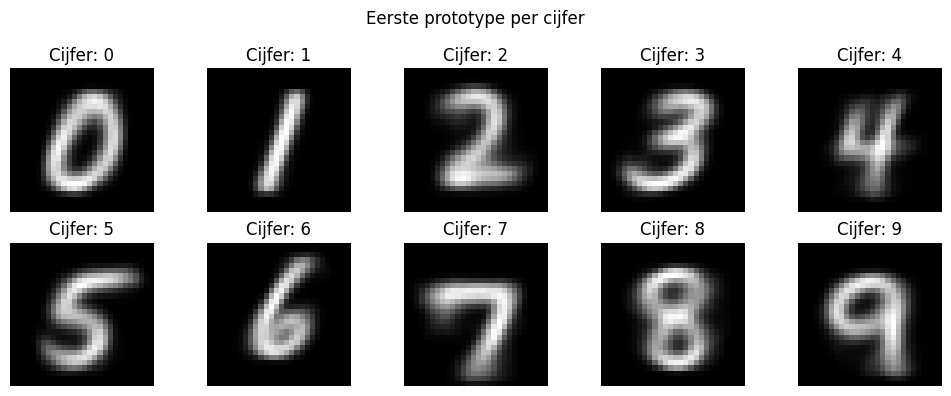

In [3]:
import matplotlib.pyplot as plt

# Gebruik de eerste 10.000 samples voor snelheid
X_train, y_train = X[:10000], y[:10000]

k = 3
prototypes, proto_labels = make_prototype(X_train, y_train, k=k)

# Laat voor elk cijfer het eerste prototype zien
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit in range(10):
    idx = np.where(proto_labels == digit)[0][0]
    ax = axes[digit // 5][digit % 5]
    ax.imshow(prototypes[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'Cijfer: {digit}')
    ax.axis('off')
plt.suptitle('Eerste prototype per cijfer')
plt.tight_layout()
plt.show()

### Stap 3 - Cijfers voorspellen

Stel we willen het cijfer voorspellen door te kijken naar de afstand tot een prototype.
Een onbekend plaatje wordt dus vergeleken met alle prototypes.

Om te beginnen moeten we een functie hebben die de afstanden tussen 2 afbeeldingen (of een lijst van pixels) berekent.

Noem de functie **get_distance(image1, image2)**. Deze geeft een getal terug die de som is van alle pixel verschillen.


In [4]:
def get_distance(image1, image2):
    return np.sum(np.abs(image1 - image2))

Schrijf een functie **predict** die:

- Voor elk testplaatje de afstand tot alle prototypes berekent

- Het prototype kiest dat het meest lijkt

- Het bijbehorende cijfer - de label van de beste prototype teruggeeft

Wat betekent afstand hier?

Waarom gebruiken we de kleinste afstand?

In [5]:
def predict(image, prototypes, proto_labels):
    distances = [get_distance(image, proto) for proto in prototypes]
    best_idx = np.argmin(distances)
    return proto_labels[best_idx]

**Wat betekent afstand hier?**

Afstand is de som van de absolute pixelverschillen tussen twee afbeeldingen. Hoe meer twee plaatjes op elkaar lijken, hoe kleiner de afstand.

**Waarom gebruiken we de kleinste afstand?**

Het prototype met de kleinste afstand lijkt het meest op het testplaatje. We gaan er van uit dat als een onbekend plaatje sterk lijkt op een prototype van een bepaald cijfer, het ook dat cijfer is.

Probeer nu een random afbeelding te voorspellen aan de hand van je **predict** functie.

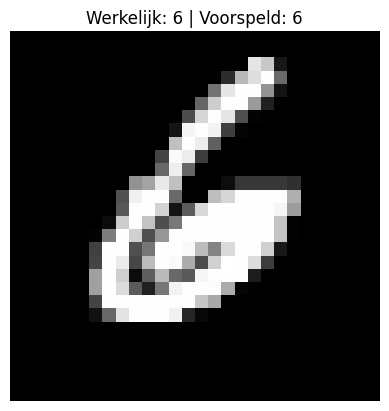

In [6]:
# Kies een willekeurige afbeelding uit de testset
random_idx = np.random.randint(10000, len(X))
test_image = X[random_idx]
true_label = y[random_idx]

predicted_label = predict(test_image, prototypes, proto_labels)

plt.imshow(test_image.reshape(28, 28), cmap='gray')
plt.title(f'Werkelijk: {true_label} | Voorspeld: {predicted_label}')
plt.axis('off')
plt.show()

### Stap 4 - Experimenteren

Schrijf code die:

- De data splitst in train en test

- Prototypes maakt (aan de hand van je eerder gemaakte functie)

- Voorspellingen doet (predict functie aanroept)

- De accuracy berekent

- Het geheugengebruik van de prototypes print

Hint:

- Accuracy = aantal juiste voorspellingen / totaal

        Tip: gebruik **accuracy = np.mean(y_pred == y_test)**

- Geheugen = array.nbytes

Test met:

k = 1, 3, 5, 10 of iets anders...


Wat gebeurt er met de accuracy als k groter wordt?

Wat gebeurt er met het geheugen?

Probeer een optimale setting te vinden en bereid hier een presentatie over.

In [7]:
from sklearn.model_selection import train_test_split

# Data splitsen in train en test (gebruik subset voor snelheid)
X_sub, y_sub = X[:10000], y[:10000]
X_train, X_test, y_train, y_test = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)

for k in [1, 3, 5, 10]:
    # Prototypes maken
    prototypes, proto_labels = make_prototype(X_train, y_train, k=k)

    # Voorspellingen doen
    y_pred = np.array([predict(img, prototypes, proto_labels) for img in X_test])

    # Accuracy berekenen
    accuracy = np.mean(y_pred == y_test)

    # Geheugengebruik
    memory = prototypes.nbytes

    print(f"k={k:2d} | Accuracy: {accuracy:.3f} | Geheugen prototypes: {memory / 1024:.1f} KB")

k= 1 | Accuracy: 0.668 | Geheugen prototypes: 61.2 KB
k= 3 | Accuracy: 0.785 | Geheugen prototypes: 183.8 KB
k= 5 | Accuracy: 0.824 | Geheugen prototypes: 306.2 KB
k=10 | Accuracy: 0.871 | Geheugen prototypes: 612.5 KB


**Wat gebeurt er met de accuracy als k groter wordt?**

De accuracy stijgt naarmate k groter wordt. Met meer prototypes per cijfer worden de subtiele variaties (bijv. verschillende schrijfstijlen) beter vastgelegd, waardoor voorspellingen nauwkeuriger worden.

**Wat gebeurt er met het geheugen?**

Het geheugengebruik stijgt lineair met k. Bij k=10 heb je 10x zoveel prototypes als bij k=1, en dus ook 10x zoveel geheugen nodig.

**Optimale setting:**

Een goede balans ligt rond k=5: de accuracy is al aanzienlijk beter dan k=1, terwijl het geheugengebruik beperkt blijft ten opzichte van de volledige dataset.